# Rendimiento de jugador — FBref Big 5 European Leagues 2024-25

Dataset real (no sintético) descargado de FBref: estadísticas estándar de
2854 jugadores de las 5 grandes ligas europeas (Premier League, La Liga,
Bundesliga, Serie A, Ligue 1) en la temporada 2024-25.

Este notebook cubre tres cosas:
1. Explicar la tabla de datos (diccionario de columnas).
2. Análisis descriptivo general.
3. Medir rendimiento de jugador (rankings, per-90, filtrando por minutos jugados).

El análisis por equipo y una explicación más profunda de jugador (percentiles
por posición, similaridad) van en un notebook aparte a continuación de este.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/raw/fbref_big5_player_standard_2025.csv")
print(df.shape)
df.head()

(2854, 26)


,ranker,player,nationality,position,team,comp_level,age,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,matches
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,86,1.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches
1,2,Max Aarons,eng ENG,DF,Valencia,es La Liga,24.0,2000.0,4,1,120,1.3,0,0,0,0,0,0,2,0,0.0,0.0,0.0,0.0,0.0,Matches
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,65,0.7,0,0,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,Matches
3,4,James Abankwah,ie IRL,DF,Udinese,it Serie A,20.0,2004.0,6,0,88,1.0,0,0,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,Matches
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,3,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches


## 1. Diccionario de datos

Cada fila es un jugador **en un equipo** (si un jugador cambió de equipo a
mitad de temporada, aparece dos veces — una fila por equipo). Columnas:

| Columna | Significado |
|---|---|
| `ranker` | Número de fila en la tabla original de FBref (no es un ranking de calidad) |
| `player` | Nombre del jugador |
| `nationality` | Código de país |
| `position` | Posición(es); puede tener varias separadas por coma (ej. `DF,MF`) |
| `team` | Equipo |
| `comp_level` | Competición/liga |
| `age` | Edad al inicio de temporada |
| `birth_year` | Año de nacimiento |
| `games` | Partidos jugados |
| `games_starts` | Partidos como titular |
| `minutes` | Minutos totales jugados |
| `minutes_90s` | Minutos jugados / 90 (equivalente a "partidos completos") |
| `goals` | Goles marcados |
| `assists` | Asistencias |
| `goals_assists` | Goles + asistencias |
| `goals_pens` | Goles sin contar penaltis |
| `pens_made` / `pens_att` | Penaltis anotados / intentados |
| `cards_yellow` / `cards_red` | Tarjetas amarillas / rojas |
| `*_per90` | La misma métrica normalizada por 90 minutos jugados |

Las columnas `_per90` son las que sirven para **comparar** jugadores con
distinta cantidad de minutos — comparar `goals` a secas penaliza a quien jugó
menos, aunque haya sido más eficiente.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ranker                    2854 non-null   int64  
 1   player                    2854 non-null   str    
 2   nationality               2852 non-null   str    
 3   position                  2854 non-null   str    
 4   team                      2854 non-null   str    
 5   comp_level                2854 non-null   str    
 6   age                       2853 non-null   float64
 7   birth_year                2853 non-null   float64
 8   games                     2854 non-null   int64  
 9   games_starts              2854 non-null   int64  
 10  minutes                   2854 non-null   str    
 11  minutes_90s               2854 non-null   float64
 12  goals                     2854 non-null   int64  
 13  assists                   2854 non-null   int64  
 14  goals_assists      

## 2. Análisis descriptivo

Estadísticos generales de las métricas numéricas, y cómo se reparten los
jugadores entre ligas y posiciones.

In [3]:
df[["age", "minutes", "minutes_90s", "goals", "assists", "goals_per90", "assists_per90"]].describe()

,age,minutes_90s,goals,assists,goals_per90,assists_per90
count,2853.000000,2854.000000,2854.000000,2854.000000,2854.000000,2854.000000
mean,24.997546,13.468430,1.684653,1.201472,0.112281,0.076689
std,4.502181,10.731516,3.156186,1.946998,0.197118,0.136580
min,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,3.500000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,11.700000,0.000000,0.000000,0.000000,0.000000
75%,28.000000,22.200000,2.000000,2.000000,0.160000,0.120000
max,41.000000,38.000000,31.000000,18.000000,2.430000,2.650000


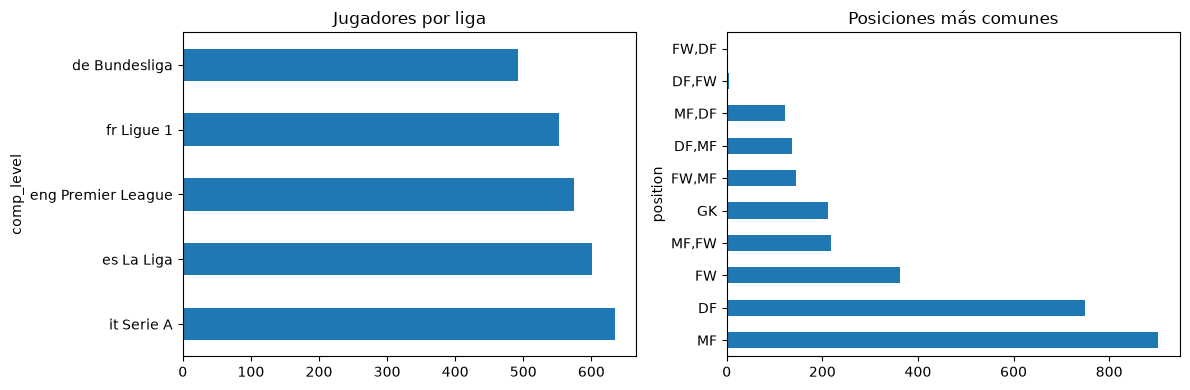

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["comp_level"].value_counts().plot(kind="barh", ax=axes[0], title="Jugadores por liga")
df["position"].value_counts().head(10).plot(kind="barh", ax=axes[1], title="Posiciones más comunes")
fig.tight_layout()

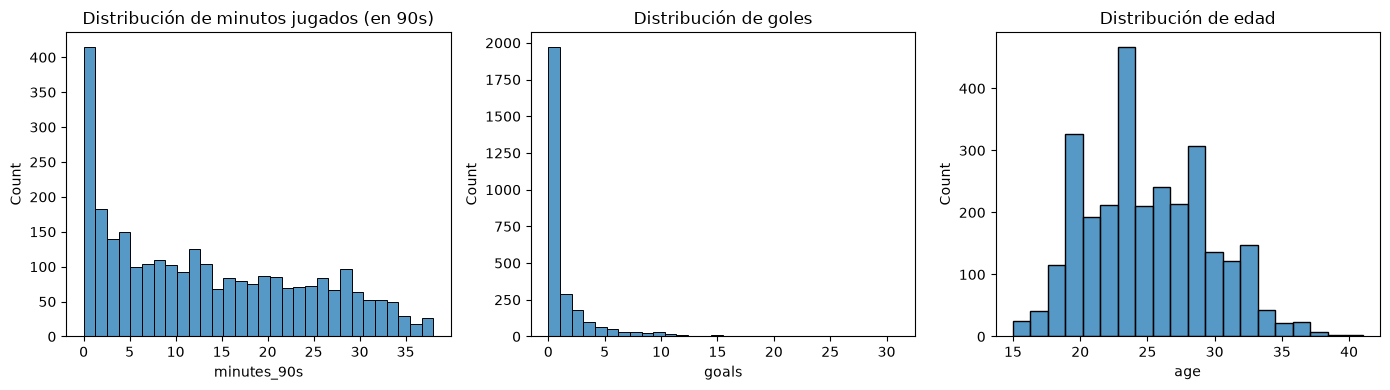

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df["minutes_90s"], bins=30, ax=axes[0])
axes[0].set_title("Distribución de minutos jugados (en 90s)")
sns.histplot(df["goals"], bins=30, ax=axes[1])
axes[1].set_title("Distribución de goles")
sns.histplot(df["age"], bins=20, ax=axes[2])
axes[2].set_title("Distribución de edad")
fig.tight_layout()

Nota sobre la distribución de minutos: está muy concentrada cerca de 0 porque
el dataset incluye a *todos* los jugadores de plantilla, incluidos suplentes
que jugaron pocos minutos. Para medir rendimiento hay que filtrar por un
mínimo de minutos — si no, un jugador con 1 gol en 10 minutos aparece con un
`goals_per90` altísimo y distorsiona cualquier ranking.

## 3. Medir rendimiento de jugador

Filtramos a jugadores con al menos 10 partidos completos (900 minutos) para
que los rankings por-90 sean comparables entre sí.

In [6]:
regulares = df[df["minutes_90s"] >= 10].copy()
print(f"{len(regulares)} de {len(df)} jugadores tienen 10+ partidos completos")

1573 de 2854 jugadores tienen 10+ partidos completos


In [7]:
top_goleadores = df.sort_values("goals", ascending=False)[["player", "team", "comp_level", "goals", "minutes_90s"]].head(10)
top_goleadores

,player,team,comp_level,goals,minutes_90s
1690,Kylian Mbappé,Real Madrid,es La Liga,31,32.3
2304,Mohamed Salah,Liverpool,eng Premier League,29,37.5
1484,Robert Lewandowski,Barcelona,es La Liga,27,29.6
1317,Harry Kane,Bayern Munich,de Bundesliga,26,26.5
2201,Mateo Retegui,Atalanta,it Serie A,25,26.5
1217,Alexander Isak,Newcastle,eng Premier League,23,30.6
1105,Erling Haaland,Manchester City,eng Premier League,22,30.4
695,Ousmane Dembélé,PSG,fr Ligue 1,21,19.2
1089,Serhou Guirassy,Dortmund,de Bundesliga,21,28.9
404,Ante Budimir,Osasuna,es La Liga,21,32.8


In [8]:
top_eficiencia = regulares.sort_values("goals_assists_per90", ascending=False)[
    ["player", "team", "comp_level", "position", "goals_assists_per90", "minutes_90s"]
].head(10)
top_eficiencia

,player,team,comp_level,position,goals_assists_per90,minutes_90s
1631,Omar Marmoush,Frankfurt,de Bundesliga,"FW,MF",1.49,16.1
695,Ousmane Dembélé,PSG,fr Ligue 1,FW,1.40,19.2
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,1.32,26.5
2611,Ferran Torres,Barcelona,es La Liga,"FW,MF",1.30,12.3
2538,Alexander Sørloth,Atlético Madrid,es La Liga,FW,1.26,17.4
2304,Mohamed Salah,Liverpool,eng Premier League,MF,1.25,37.5
2201,Mateo Retegui,Atalanta,it Serie A,FW,1.25,26.5
2370,Patrik Schick,Leverkusen,de Bundesliga,FW,1.12,18.7
1042,Amine Gouiri,Marseille,fr Ligue 1,FW,1.12,11.6
2171,Gonçalo Ramos,PSG,fr Ligue 1,FW,1.10,11.8


Compara `top_goleadores` (goles totales, favorece a quien jugó más) contra
`top_eficiencia` (G+A por 90, favorece al más productivo por minuto) — son
rankings distintos a propósito, y la diferencia entre ambos es justamente lo
que se quiere "explicar" al medir rendimiento de un jugador.

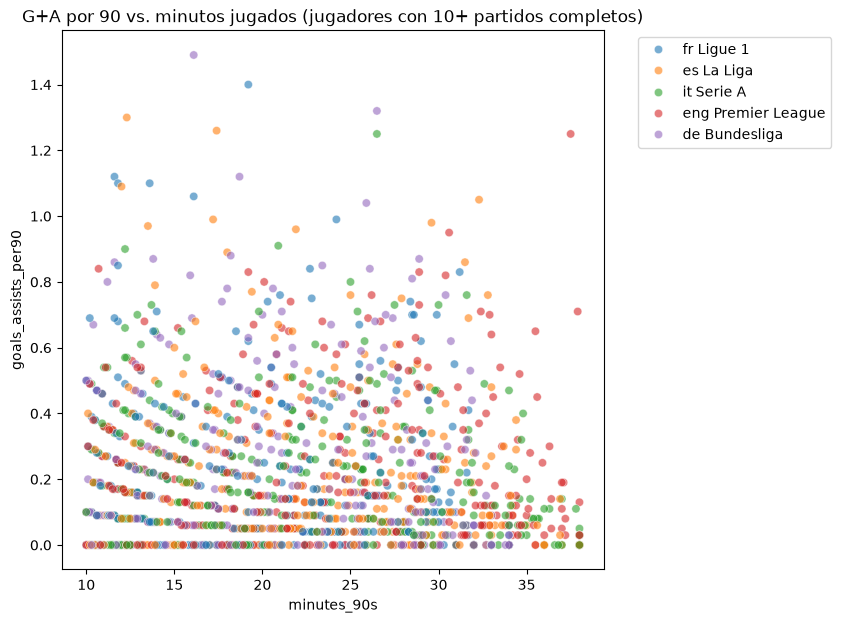

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(data=regulares, x="minutes_90s", y="goals_assists_per90", hue="comp_level", alpha=0.6, ax=ax)
ax.set_title("G+A por 90 vs. minutos jugados (jugadores con 10+ partidos completos)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

## Siguiente paso

- **Equipos**: agregar este mismo dataset por `team` (suma de goles, edad
  promedio de plantilla, etc.) para comparar entre clubes — va en el
  siguiente notebook.
- **Jugadores, más a fondo**: percentiles por posición y comparación tipo
  scouting, reemplazando los datos sintéticos de
  `06_scouting_percentiles_similaridad.ipynb` por este CSV real.